# Netflix Content Strategy & Trend Analysis

## Project Overview

This project analyzes Netflix's movies and TV shows dataset to identify important trends in content production and distribution.

### Objectives

- Analyze the growth of Netflix content over the years
- Compare Movies and TV Shows
- Identify the most popular genres
- Analyze content by country
- Study content ratings and duration
- Identify major trends and patterns
- Generate business-oriented insights from the data

### Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Project Type

Exploratory Data Analysis (EDA)

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("netflix_titles.csv")

In [5]:
df.head()

,Show Id,Title,Description,Director,Genres,Cast,Production Country,Release Date,Rating,Duration,Imdb Score,Content Type,Date Added
0,cc1b6ed9-cf9e-4057-8303-34577fb54477,(Un)Well,This docuseries takes a deep dive into the luc...,NaN,Reality TV,NaN,United States,2020.0,TV-MA,1 Season,6.6/10,TV Show,NaN
1,e2ef4e91-fb25-42ab-b485-be8e3b23dedb,#Alive,"As a grisly virus rampages a city, a lone man ...",Cho Il,"Horror Movies, International Movies, Thrillers","Yoo Ah-in, Park Shin-hye",South Korea,2020.0,TV-MA,99 min,6.2/10,Movie,"September 8, 2020"
2,b01b73b7-81f6-47a7-86d8-acb63080d525,#AnneFrank - Parallel Stories,"Through her diary, Anne Frank's story is retol...","Sabina Fedeli, Anna Migotto","Documentaries, International Movies","Helen Mirren, Gengher Gatti",Italy,2019.0,TV-14,95 min,6.4/10,Movie,"July 1, 2020"
3,b6611af0-f53c-4a08-9ffa-9716dc57eb9c,#blackAF,Kenya Barris and his family navigate relations...,NaN,TV Comedies,"Kenya Barris, Rashida Jones, Iman Benson, Genn...",United States,2020.0,TV-MA,1 Season,6.6/10,TV Show,NaN
4,7f2d4170-bab8-4d75-adc2-197f7124c070,#cats_the_mewvie,This pawesome documentary explores how our fel...,Michael Margolis,"Documentaries, International Movies",NaN,Canada,2020.0,TV-14,90 min,5.1/10,Movie,"February 5, 2020"


In [6]:
df.shape

(5967, 13)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5967 entries, 0 to 5966
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Show Id             5967 non-null   str    
 1   Title               5967 non-null   str    
 2   Description         5967 non-null   str    
 3   Director            3903 non-null   str    
 4   Genres              5967 non-null   str    
 5   Cast                5437 non-null   str    
 6   Production Country  5408 non-null   str    
 7   Release Date        5964 non-null   float64
 8   Rating              5963 non-null   str    
 9   Duration            5964 non-null   str    
 10  Imdb Score          5359 non-null   str    
 11  Content Type        5967 non-null   str    
 12  Date Added          4632 non-null   str    
dtypes: float64(1), str(12)
memory usage: 2.8 MB


In [8]:
df.isnull().sum()

Show Id                  0
Title                    0
Description              0
Director              2064
Genres                   0
Cast                   530
Production Country     559
Release Date             3
Rating                   4
Duration                 3
Imdb Score             608
Content Type             0
Date Added            1335
dtype: int64

In [9]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Show Id,5967,5967,cc1b6ed9-cf9e-4057-8303-34577fb54477,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,5967,5897,Wild Dog,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,5967,5946,A brash but brilliant Indian intelligence agen...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Director,3903,2993,"Raúl Campos, Jan Suter",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,5967,433,Stand-Up Comedy,320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cast,5437,5245,Jeff Dunham,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Production Country,5408,509,United States,1792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Release Date,5964.0,NaN,NaN,NaN,2015.643863,7.257391,1925.0,2015.0,2018.0,2019.0,2021.0
Rating,5963,11,TV-MA,2541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,5964,207,1 Season,1374,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

Show Id                   str
Title                     str
Description               str
Director                  str
Genres                    str
Cast                      str
Production Country        str
Release Date          float64
Rating                    str
Duration                  str
Imdb Score                str
Content Type              str
Date Added                str
dtype: object

In [12]:
df['Imdb Score'] = df['Imdb Score'].str.replace('/10', '', regex=False)
df['Imdb Score'] = pd.to_numeric(df['Imdb Score'], errors='coerce')

df['Imdb Score'].head()

0    6.6
1    6.2
2    6.4
3    6.6
4    5.1
Name: Imdb Score, dtype: float64

In [13]:
df['Date Added'] = pd.to_datetime(df['Date Added'], errors='coerce')

df[['Release Date', 'Date Added']].head()

,Release Date,Date Added
0,2020.0,NaT
1,2020.0,2020-09-08
2,2019.0,2020-07-01
3,2020.0,NaT
4,2020.0,2020-02-05


In [14]:
df['Release Date'] = df['Release Date'].astype('Int64')

df['Release Date'].head()

0    2020
1    2020
2    2019
3    2020
4    2020
Name: Release Date, dtype: Int64

In [15]:
df['Duration'].value_counts().head(10)

Duration
1 Season     1374
2 Seasons     357
3 Seasons     163
102 min        92
97 min         91
93 min         91
94 min         88
95 min         83
4 Seasons      83
90 min         81
Name: count, dtype: int64

In [16]:
# Extract numeric value from Duration
df['Duration_Value'] = pd.to_numeric(
    df['Duration'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

# Extract duration unit
df['Duration_Unit'] = df['Duration'].str.extract(r'(min|Season|Seasons)')[0]

df[['Duration', 'Duration_Value', 'Duration_Unit']].head(10)

,Duration,Duration_Value,Duration_Unit
0,1 Season,1.0,Season
1,99 min,99.0,min
2,95 min,95.0,min
3,1 Season,1.0,Season
4,90 min,90.0,min
5,102 min,102.0,min
6,104 min,104.0,min
7,99 min,99.0,min
8,56 min,56.0,min
9,125 min,125.0,min


In [17]:
df['Content Type'].value_counts()

Content Type
Movie      3867
TV Show    2100
Name: count, dtype: int64

In [18]:
df['Genres'].value_counts().head(15)

Genres
Stand-Up Comedy                                      320
Dramas, International Movies                         249
Comedies, Dramas, International Movies               211
Documentaries                                        189
Dramas, Independent Movies, International Movies     159
Kids' TV                                             156
Dramas, International Movies, Romantic Movies        136
Children & Family Movies, Comedies                   129
Comedies, International Movies                       125
Comedies, International Movies, Romantic Movies      119
Documentaries, International Movies                   99
Dramas, International Movies, Thrillers               98
Children & Family Movies                              97
International TV Shows, TV Dramas                     97
Crime TV Shows, International TV Shows, TV Dramas     96
Name: count, dtype: int64

In [19]:
df['Production Country'].value_counts().head(15)

Production Country
United States     1792
India              628
United Kingdom     244
Japan              221
South Korea        167
Spain              129
Canada             107
France              95
Nigeria             86
Mexico              82
Turkey              77
Taiwan              75
Philippines         70
Brazil              68
Egypt               67
Name: count, dtype: int64

In [20]:
df['Release Date'].value_counts().sort_index().tail(15)

Release Date
2007     45
2008     76
2009     89
2010     89
2011     95
2012    129
2013    131
2014    187
2015    277
2016    491
2017    661
2018    924
2019    971
2020    946
2021    416
Name: count, dtype: Int64

In [22]:
pip install matplotlib 

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.5 MB 5.8 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.5 MB 6.7 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.5 MB 7.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.6 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------- -------------- 1.6/2.5 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 8.5 MB/s  0:00:00
U

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


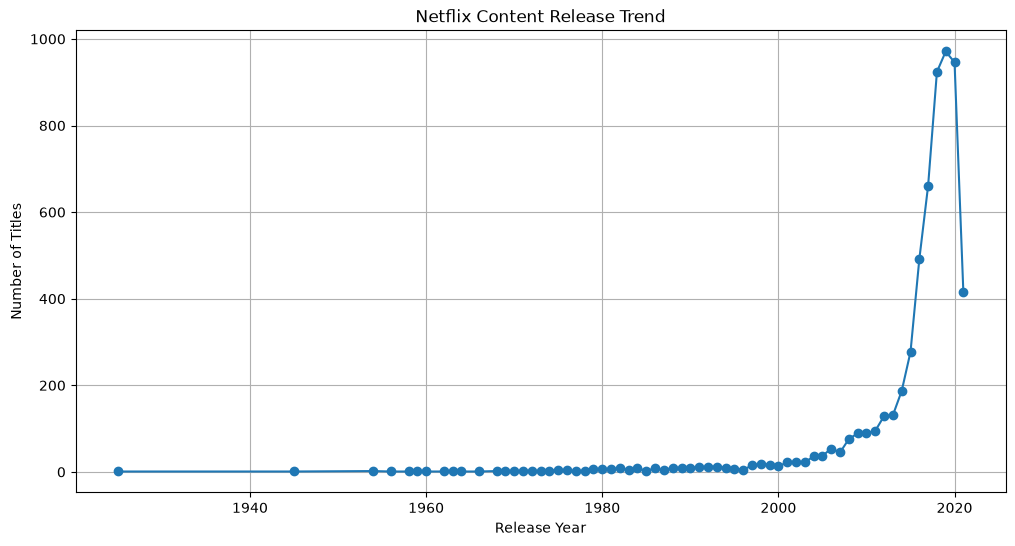

In [23]:
import matplotlib.pyplot as plt

release_year_counts = df['Release Date'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(
    release_year_counts.index,
    release_year_counts.values,
    marker='o'
)

plt.title('Netflix Content Release Trend')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()

In [24]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
df.groupby(['Release Date', 'Content Type']).size().unstack(fill_value=0).tail(15)

Content Type,Movie,TV Show
Release Date,,
2007,36,9
2008,59,17
2009,69,20
2010,69,20
2011,72,23
2012,95,34
2013,101,30
2014,141,46
2015,187,90


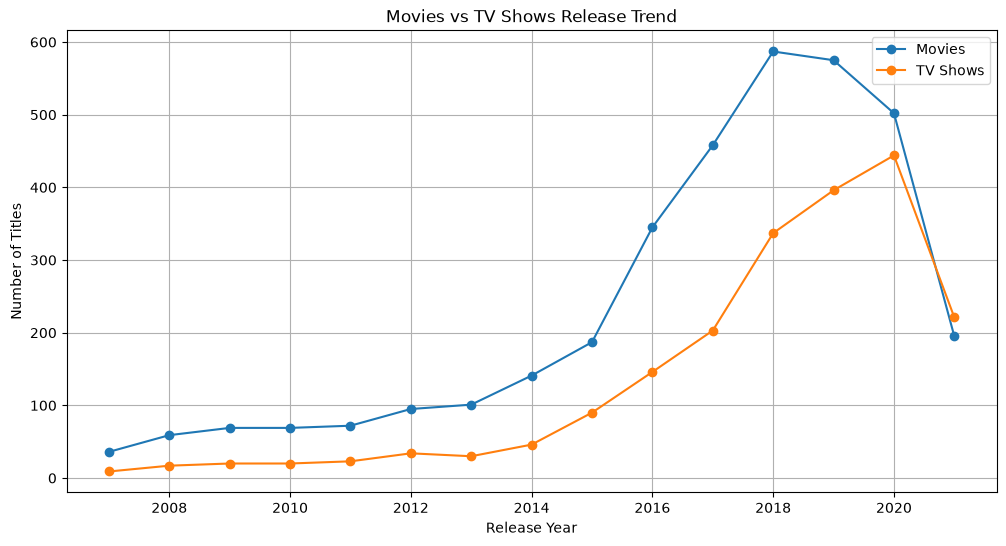

In [26]:
content_trend = df.groupby(
    ['Release Date', 'Content Type']
).size().unstack(fill_value=0)

content_trend = content_trend.tail(15)

plt.figure(figsize=(12, 6))

plt.plot(
    content_trend.index,
    content_trend['Movie'],
    marker='o',
    label='Movies'
)

plt.plot(
    content_trend.index,
    content_trend['TV Show'],
    marker='o',
    label='TV Shows'
)

plt.title('Movies vs TV Shows Release Trend')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.legend()
plt.grid(True)
plt.show()

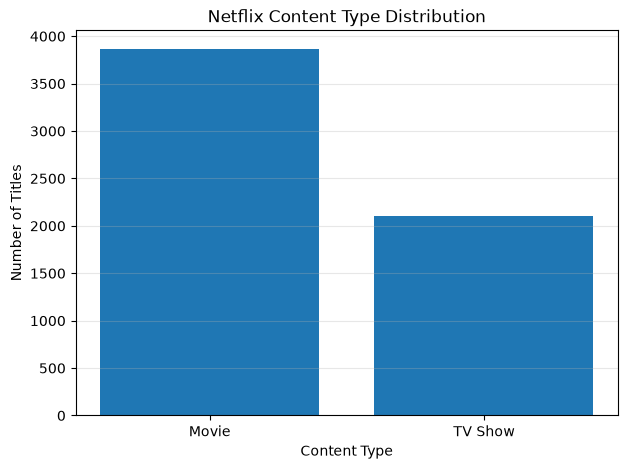

In [27]:
# Content Type Distribution

content_type_counts = df['Content Type'].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    content_type_counts.index,
    content_type_counts.values
)

plt.title('Netflix Content Type Distribution')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.grid(axis='y', alpha=0.3)

plt.show()

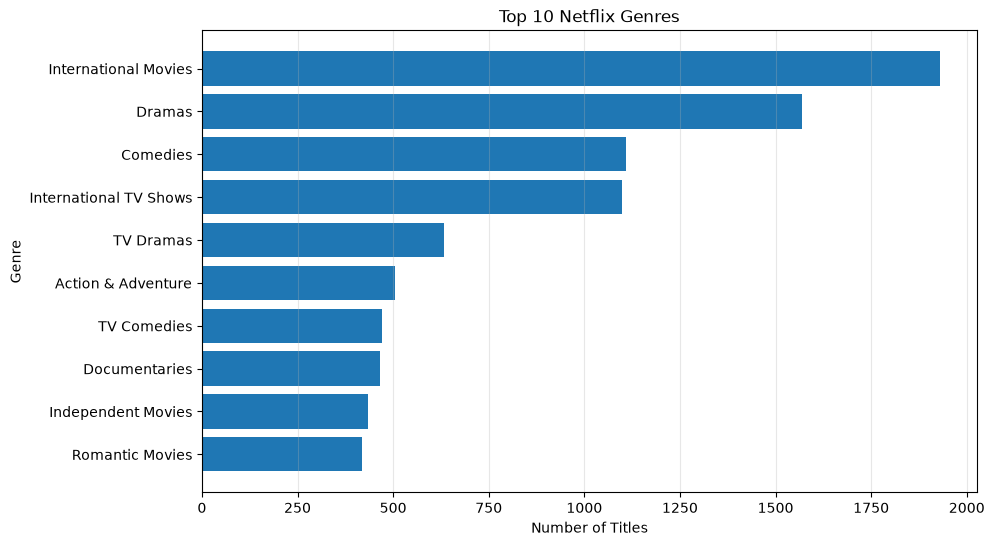

In [28]:
# Top 10 Genres

genre_counts = (
    df['Genres']
    .dropna()
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    genre_counts.index[::-1],
    genre_counts.values[::-1]
)

plt.title('Top 10 Netflix Genres')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.grid(axis='x', alpha=0.3)

plt.show()

In [30]:
df.columns.tolist()

['Show Id',
 'Title',
 'Description',
 'Director',
 'Genres',
 'Cast',
 'Production Country',
 'Release Date',
 'Rating',
 'Duration',
 'Imdb Score',
 'Content Type',
 'Date Added',
 'Duration_Value',
 'Duration_Unit']

In [31]:
df['Production Country'].value_counts().head(15)

Production Country
United States     1792
India              628
United Kingdom     244
Japan              221
South Korea        167
Spain              129
Canada             107
France              95
Nigeria             86
Mexico              82
Turkey              77
Taiwan              75
Philippines         70
Brazil              68
Egypt               67
Name: count, dtype: int64

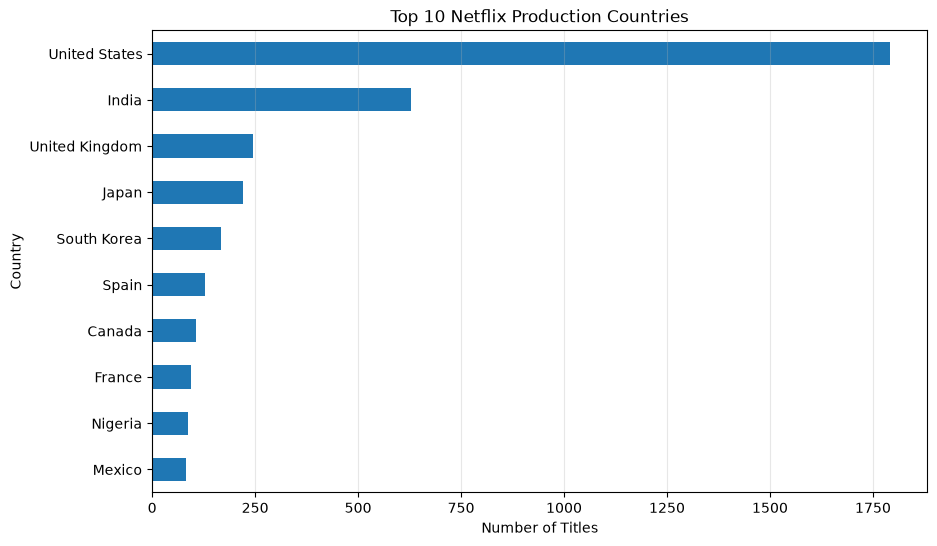

In [32]:
top_countries = df['Production Country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_countries.sort_values().plot(kind='barh')

plt.title('Top 10 Netflix Production Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)

plt.show()

In [33]:
df['Rating'].value_counts()

Rating
TV-MA    2541
TV-14    1551
TV-PG     527
R         385
TV-Y      240
PG-13     226
TV-Y7     206
TV-G      146
PG        125
G          15
NC-17       1
Name: count, dtype: int64

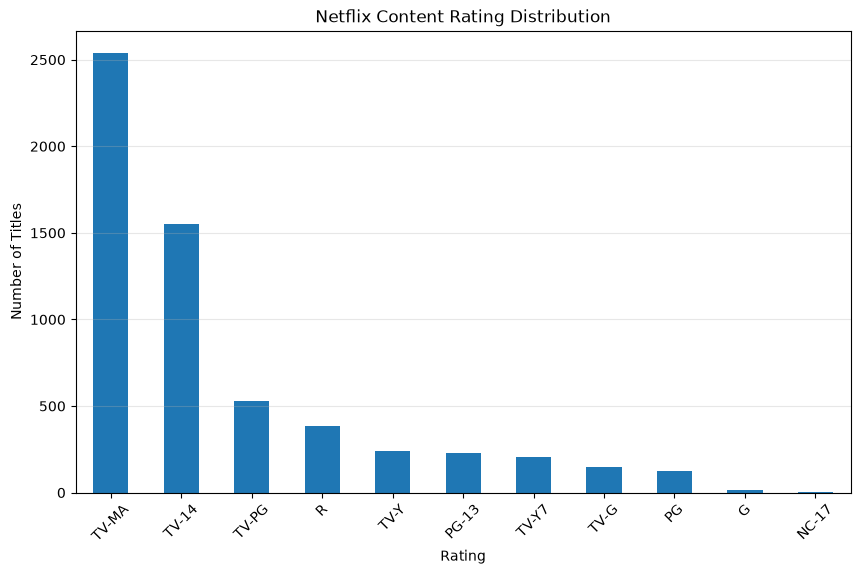

In [34]:
rating_counts = df['Rating'].value_counts()

plt.figure(figsize=(10, 6))

rating_counts.plot(kind='bar')

plt.title('Netflix Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

In [36]:
df['Duration_Unit'].value_counts()

Duration_Unit
min       3867
Season    2097
Name: count, dtype: int64

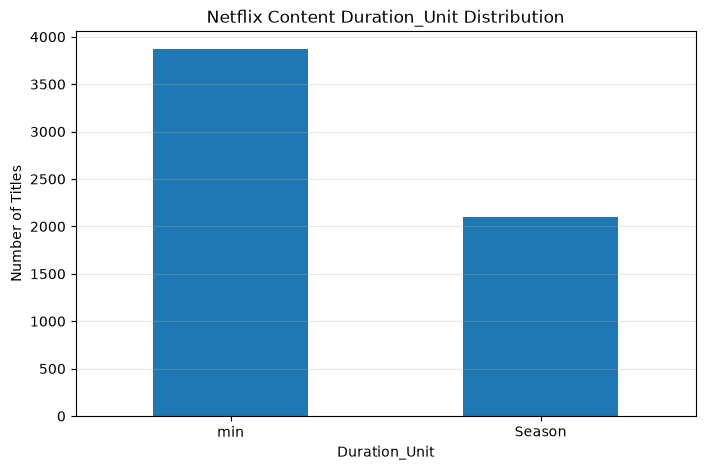

In [37]:
duration_counts = df['Duration_Unit'].value_counts()

plt.figure(figsize=(8, 5))

duration_counts.plot(kind='bar')

plt.title('Netflix Content Duration_Unit Distribution')
plt.xlabel('Duration_Unit')
plt.ylabel('Number of Titles')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

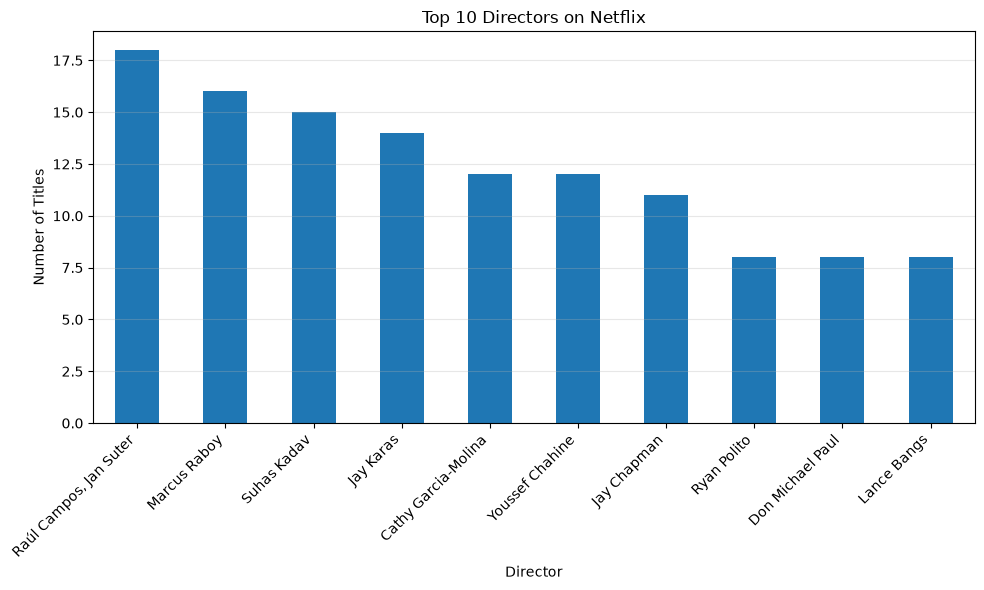

In [38]:
# Top 10 Directors on Netflix

top_directors = df['Director'].value_counts().head(10)

plt.figure(figsize=(10, 6))

top_directors.plot(kind='bar')

plt.title('Top 10 Directors on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

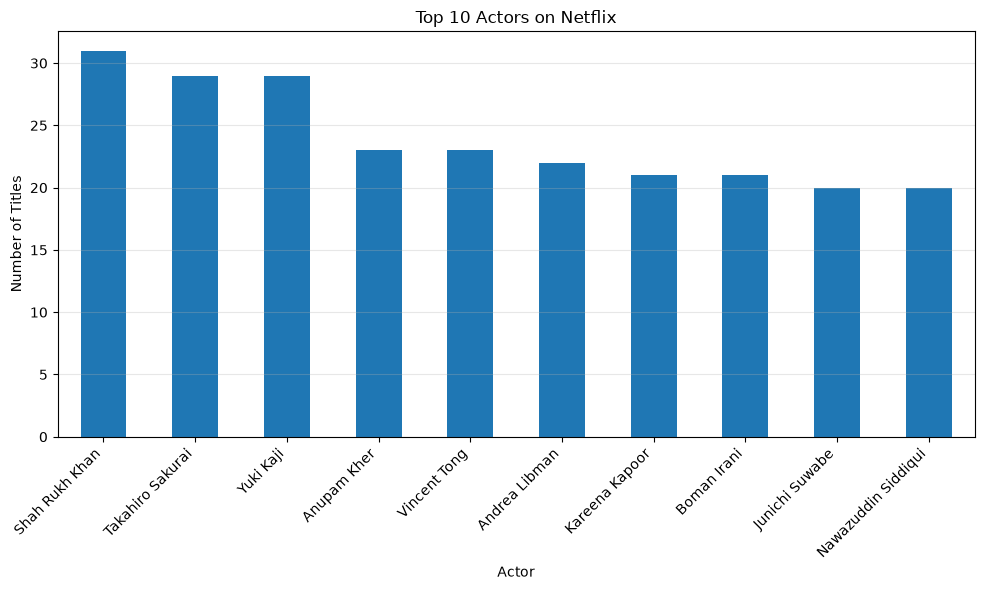

In [39]:
# Top 10 Actors on Netflix

top_actors = (
    df['Cast']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

top_actors.plot(kind='bar')

plt.title('Top 10 Actors on Netflix')
plt.xlabel('Actor')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

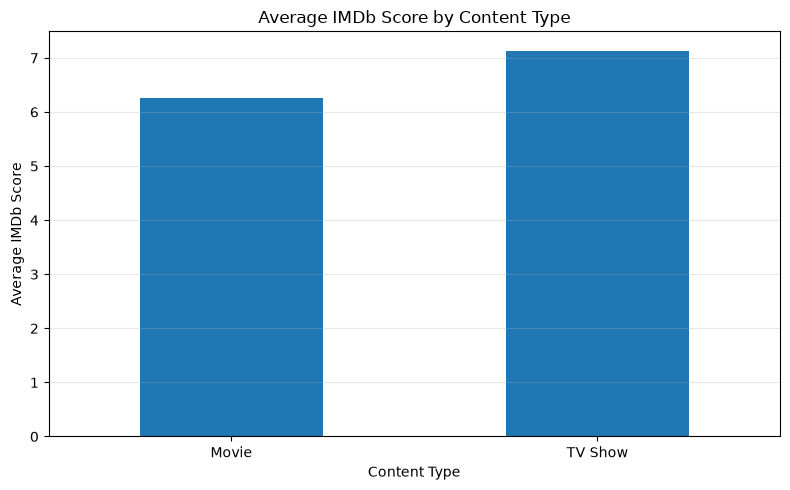

In [40]:
# Average IMDb Score by Content Type

avg_imdb = df.groupby('Content Type')['Imdb Score'].mean()

plt.figure(figsize=(8, 5))

avg_imdb.plot(kind='bar')

plt.title('Average IMDb Score by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Average IMDb Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

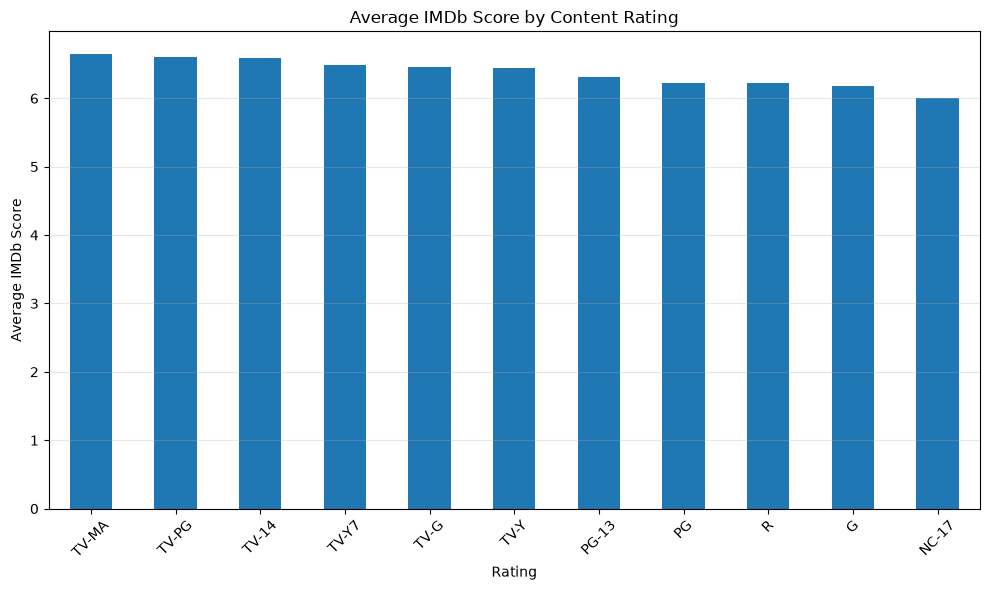

In [41]:
# Average IMDb Score by Rating

avg_rating_imdb = df.groupby('Rating')['Imdb Score'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

avg_rating_imdb.plot(kind='bar')

plt.title('Average IMDb Score by Content Rating')
plt.xlabel('Rating')
plt.ylabel('Average IMDb Score')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
top_countries = df['Production Country'].value_counts().head(10)

top_countries

Production Country
United States     1792
India              628
United Kingdom     244
Japan              221
South Korea        167
Spain              129
Canada             107
France              95
Nigeria             86
Mexico              82
Name: count, dtype: int64

In [43]:
top_countries_share = (top_countries / top_countries.sum() * 100).round(2)

top_countries_share

Production Country
United States     50.46
India             17.69
United Kingdom     6.87
Japan              6.22
South Korea        4.70
Spain              3.63
Canada             3.01
France             2.68
Nigeria            2.42
Mexico             2.31
Name: count, dtype: float64

In [44]:
content_type_counts = df['Content Type'].value_counts()

content_type_counts

Content Type
Movie      3867
TV Show    2100
Name: count, dtype: int64

In [45]:
content_type_percentage = (
    content_type_counts / content_type_counts.sum() * 100
).round(2)

content_type_percentage

Content Type
Movie      64.81
TV Show    35.19
Name: count, dtype: float64

In [46]:
content_year_trend = (
    df.groupby(['Release Date', 'Content Type'])
      .size()
      .unstack(fill_value=0)
)

content_year_trend.tail()

Content Type,Movie,TV Show
Release Date,,
2017,458,203
2018,587,337
2019,575,396
2020,502,444
2021,195,221


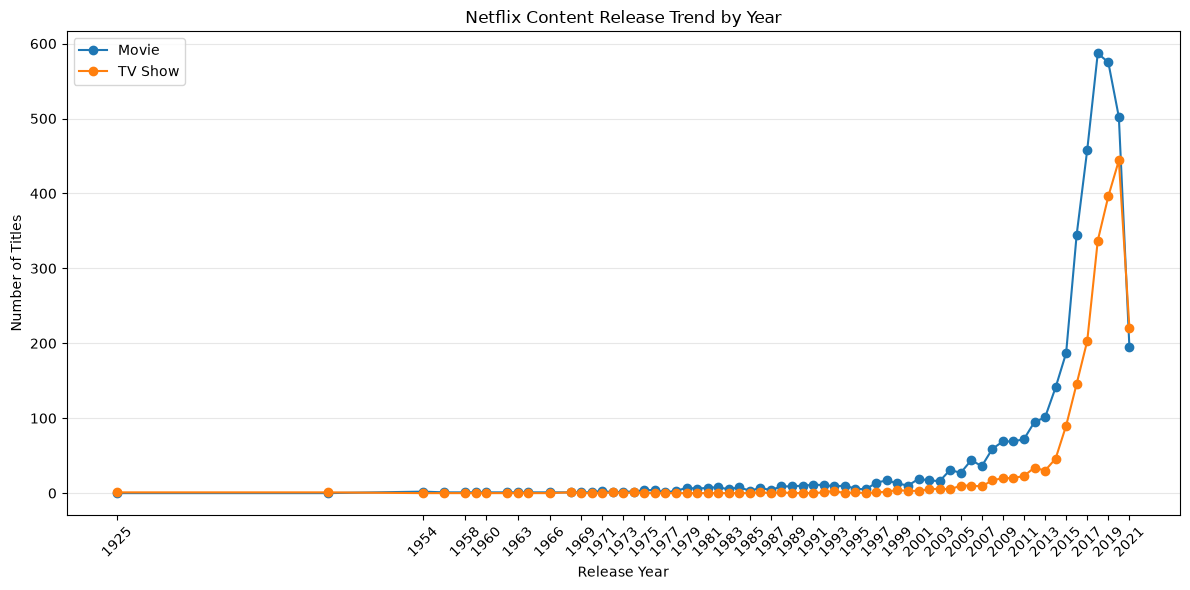

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(
    content_year_trend.index,
    content_year_trend['Movie'],
    marker='o',
    label='Movie'
)

plt.plot(
    content_year_trend.index,
    content_year_trend['TV Show'],
    marker='o',
    label='TV Show'
)

plt.title('Netflix Content Release Trend by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.xticks(
    content_year_trend.index[::2],
    rotation=45
)

plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

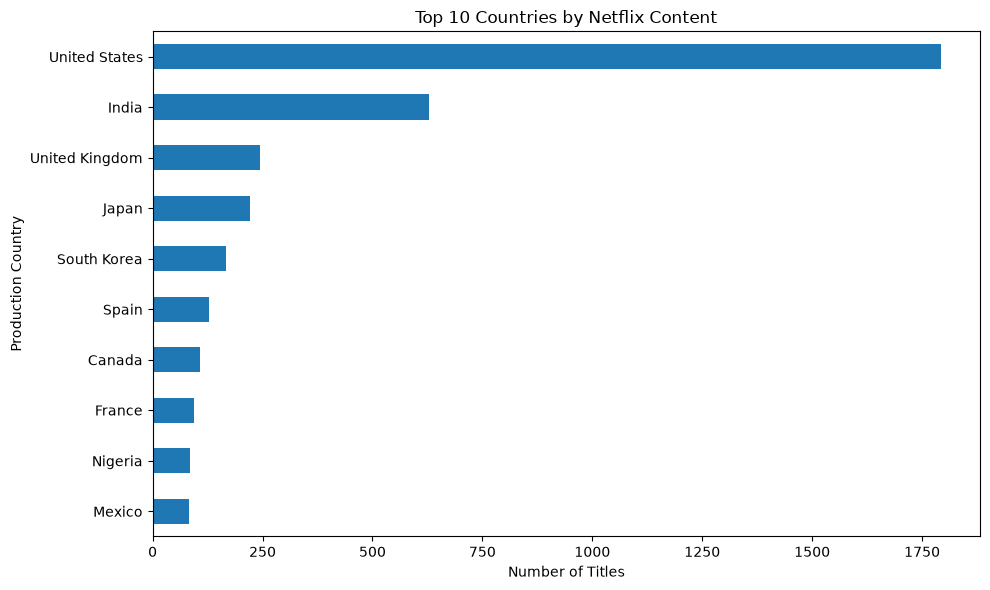

In [49]:
plt.figure(figsize=(10, 6))

top_countries.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Production Country')

plt.tight_layout()
plt.show()

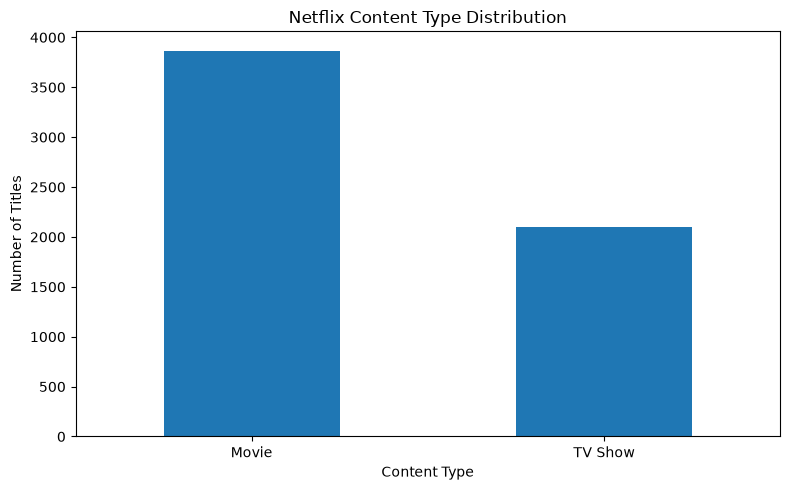

In [50]:
plt.figure(figsize=(8, 5))

content_type_counts.plot(
    kind='bar'
)

plt.title('Netflix Content Type Distribution')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [52]:
rating_counts = df['Rating'].value_counts()

rating_counts

Rating
TV-MA    2541
TV-14    1551
TV-PG     527
R         385
TV-Y      240
PG-13     226
TV-Y7     206
TV-G      146
PG        125
G          15
NC-17       1
Name: count, dtype: int64

In [53]:
top_ratings = rating_counts.head(5)

top_ratings

Rating
TV-MA    2541
TV-14    1551
TV-PG     527
R         385
TV-Y      240
Name: count, dtype: int64

In [54]:
total_rated = rating_counts.sum()

rating_percentage = (top_ratings / total_rated * 100).round(2)

rating_percentage

Rating
TV-MA    42.61
TV-14    26.01
TV-PG     8.84
R         6.46
TV-Y      4.02
Name: count, dtype: float64

## Key Insights

- Movies dominate the Netflix dataset, accounting for approximately 64.81% of the content.
- The United States is the largest contributor of Netflix content, followed by India and the United Kingdom.
- Netflix content releases increased significantly in recent years, with a major peak around 2018–2019.
- TV-MA is the most common content rating, followed by TV-14.
- The data shows a strong focus on mature and teen-oriented content.

## Business Recommendations

- Continue investing in Movies, as they represent the majority of the content library.
- Focus on high-performing markets such as the United States and India for content acquisition.
- Increase the production of TV Shows to maintain a balanced content portfolio.
- Create more content targeting mature and young-adult audiences based on rating distribution.
- Use recent release trends to identify growing content categories and audience preferences.

## Conclusion

This exploratory data analysis provides a clear overview of Netflix's content library, including content types, production countries, release trends, and audience ratings.

The analysis shows that Movies form the majority of the catalog, while the United States and India are among the leading content-producing countries. Netflix also experienced strong growth in content releases in recent years.

These insights can help understand Netflix's content strategy and support data-driven decisions related to content acquisition, production, and audience targeting.